# Classification using Tensorflow

In [15]:
import tensorflow as tf

In [16]:
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples, noise=0.03, random_state=42)

import pandas as pd
circles = pd.DataFrame({"X0": X[:, 0], "X1": X[:, 1], "label": y})

circles

,X0,X1,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
...,...,...,...
995,0.244054,0.944125,0
996,-0.978655,-0.272373,0
997,-0.136900,-0.810012,1
998,0.670362,-0.767502,0


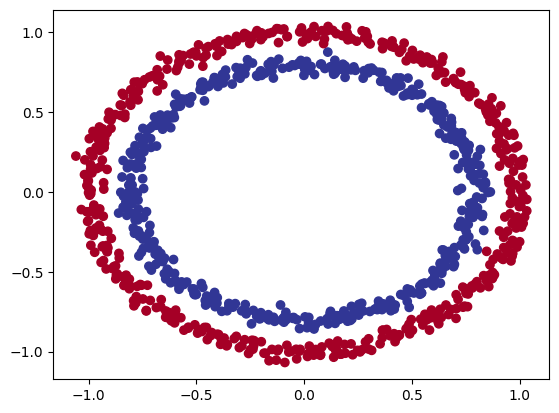

In [17]:
from matplotlib.colors import Colormap
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu)

In [18]:
## Building a Model
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

model.compile(loss=tf.keras.losses.BinaryCrossentropy(),
              optimizer=tf.keras.optimizers.Adam(),
              metrics=['accuracy'])

history = model.fit(X, y, epochs=100, verbose=0)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4650 - loss: 4.4421
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4670 - loss: 4.0707
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4710 - loss: 3.3634
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4710 - loss: 1.3371
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4630 - loss: 0.7879
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4540 - loss: 0.7648
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4510 - loss: 0.7500
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4470 - loss: 0.7385
Epoch 9/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4430 - loss: 0.7293
Epoch 10/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4380 - loss: 0.7219
Epoch 11/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4310 - loss: 0.7159
Epoch 12/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy:

In [25]:
# Creating Model 1 Traning for longer
model.fit(X, y, epochs=200, verbose=0)
model.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4890 - loss: 0.6933 


[0.6932553648948669, 0.48899999260902405]

In [20]:
tf.random.set_seed(42)

model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

model_1.compile(loss=tf.keras.losses.BinaryCrossentropy(),
              optimizer=tf.keras.optimizers.Adam(),
              metrics=['accuracy'])

history_1 = model_1.fit(X, y, epochs=100, verbose=0)
model_1.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4860 - loss: 0.6944  


[0.6943525075912476, 0.4860000014305115]

In [33]:
tf.random.set_seed(42)

model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(1)
])

model_2.compile(loss=tf.keras.losses.BinaryCrossentropy(),
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              metrics=['accuracy'])

history_2 = model_2.fit(X, y, epochs=100, verbose=0)
model_2.evaluate(X, y)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5000 - loss: 7.9712  


[7.971191883087158, 0.5]

In [34]:
# Function to visualize the decision boundary of a trained model
def plot_decision_boundary(model, X, y):
  import numpy as np
  import matplotlib.pyplot as plt
  import tensorflow as tf # Import tensorflow for tf.squeeze if not already imported globally

  # Define the axis boundaries of the plot based on the input data X
  # We add a small margin (0.1) to ensure all data points are visible.
  x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
  y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1

  # Create a meshgrid: This generates a grid of points (xx, yy) over the entire plot area.
  # The model will make predictions for each of these points to draw the decision boundary.
  xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                      np.linspace(y_min, y_max, 100))

  # Prepare input for the model: This converts the 2D grid points into a flat array of (x, y) coordinates.
  # Fix 1: The original code `np.c_[[xx.ravel(), yy.ravel()]]` created a shape (2, 10000)
  # (2 samples, 10000 features each). The model expects (number_of_samples, number_of_features),
  # so it should be (10000, 2). Removing the outer list `[]` corrects this.
  x_in = np.c_[xx.ravel(), yy.ravel()]

  # Make predictions on the grid points using the provided model.
  y_pred = model.predict(x_in)

  # Process predictions to get class labels and reshape them back to the grid shape.
  # This is crucial for plotting the decision regions.
  if y_pred.shape[-1] == 1: # This condition typically indicates binary classification (single output neuron)
    # For binary classification, model.predict often outputs probabilities (e.g., between 0 and 1).
    # We convert these probabilities to class labels (0 or 1) by applying a threshold (e.g., 0.5).
    # tf.squeeze removes single-dimensional entries from the shape of an array.
    p_pred = (tf.squeeze(y_pred) > 0.5).numpy().reshape(xx.shape)
  else: # This condition handles multi-class classification (multiple output neurons with softmax)
    # In multi-class, we take the index of the highest probability as the predicted class.
    print("doing multiclass classification") # Original print statement kept for context
    p_pred = np.argmax(y_pred, axis=1).reshape(xx.shape)

  # Plot the decision boundary.
  # Fix 2: Typo - `plt.countourf` should be `plt.contourf`.
  # Fix 3: The third argument to `contourf` should be `p_pred` (the model's predictions on the grid),
  # not `y` (the original true labels). Plotting `y` would show contours based on the original data distribution,
  # not the model's learned decision regions.
  plt.contourf(xx, yy, p_pred, cmap=plt.cm.RdYlBu, alpha=0.7)

  # Plot the original data points on top of the decision boundary.
  # `c=y` colors the points according to their true labels.
  plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)

  # Set plot limits to match the meshgrid boundaries.
  plt.xlim(xx.min(), xx.max())
  plt.ylim(yy.min(), yy.max())

  # Display the plot.
  plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


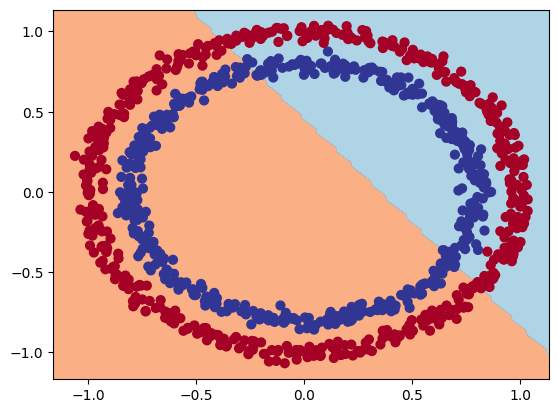

In [37]:
plot_decision_boundary(model, X, y)

## Introduction to non-linearity
